# Notebook 04 — Customer Segmentation
**Project:** Unlocking Behavioral Intelligence in Airline Loyalty Programs  
**Purpose:** Group members into meaningful segments using K-means clustering on behavioral features. Each segment gets a business-readable name and a specific retention intervention in the playbook.


## 1. Imports & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

BASE    = Path.home() / "airline-loyalty-intelligence"
PROC    = BASE / "data" / "processed"
FIG_DIR = BASE / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120})

master = pd.read_csv(PROC / "master_features.csv")
print(f"Master loaded: {master.shape}")
print(f"Risk tier distribution:")
print(master["risk_tier"].value_counts().sort_index())


Master loaded: (16737, 43)
Risk tier distribution:
risk_tier
Critical     433
High        3423
Low         7863
Medium      5018
Name: count, dtype: int64


## 2. Select clustering features
We cluster on behavioral features only — not CLV or demographics. This ensures segments are defined by what members DO, not who they are.

In [2]:
CLUSTER_FEATURES = [
    "activity_rate",
    "recency_months",
    "redemption_rate",
    "activity_trend",
    "avg_flights_last6m",
    "seasonal_concentration",
    "total_flights",
    "tenure_months"
]

X_cluster = master[CLUSTER_FEATURES].copy()

# Scale features — K-means is distance-based so scaling is mandatory
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Clustering features:", CLUSTER_FEATURES)
print("Scaled matrix shape:", X_scaled.shape)


Clustering features: ['activity_rate', 'recency_months', 'redemption_rate', 'activity_trend', 'avg_flights_last6m', 'seasonal_concentration', 'total_flights', 'tenure_months']
Scaled matrix shape: (16737, 8)


## 3. Find optimal number of clusters
Using both the Elbow method (inertia) and Silhouette score to pick k.

k=2  inertia=96159  silhouette=0.4212
k=3  inertia=73693  silhouette=0.3897
k=4  inertia=59125  silhouette=0.4305
k=5  inertia=51102  silhouette=0.3142
k=6  inertia=45084  silhouette=0.3202
k=7  inertia=40695  silhouette=0.2635
k=8  inertia=37363  silhouette=0.2646


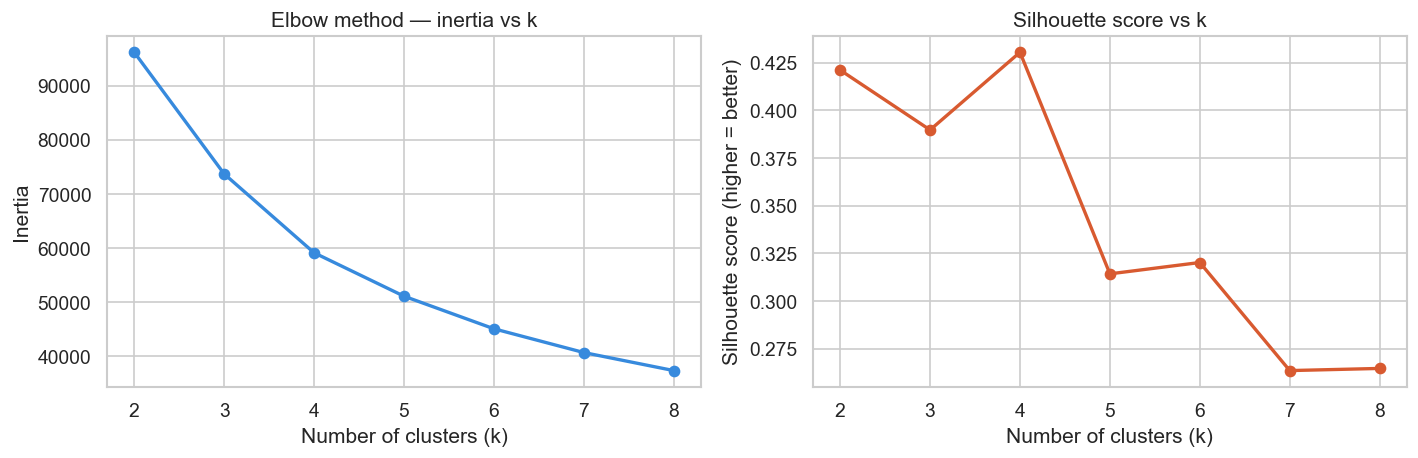


Best k by silhouette score: 4


In [3]:
inertias    = []
silhouettes = []
K_range     = range(2, 9)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl, sample_size=2000, random_state=42))
    print(f"k={k}  inertia={km.inertia_:.0f}  silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, marker="o", color="#378ADD", linewidth=2)
axes[0].set_title("Elbow method — inertia vs k")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(K_range, silhouettes, marker="o", color="#D85A30", linewidth=2)
axes[1].set_title("Silhouette score vs k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score (higher = better)")

plt.tight_layout()
plt.savefig(FIG_DIR / "09_optimal_k.png", bbox_inches="tight")
plt.show()

best_k = K_range[silhouettes.index(max(silhouettes))]
print(f"\nBest k by silhouette score: {best_k}")


## 4. Fit final K-means model

In [4]:
K_FINAL = 5

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
master["cluster"] = km_final.fit_predict(X_scaled)

print("Cluster distribution:")
print(master["cluster"].value_counts().sort_index())


Cluster distribution:
cluster
0     648
1    3814
2    1937
3    1619
4    8719
Name: count, dtype: int64


## 5. Profile each cluster
Understand what each cluster actually looks like in terms of behavior, CLV, and churn risk.

In [5]:
profile_cols = CLUSTER_FEATURES + ["CLV", "churn_probability", "churned_behavioral"]

profile = master.groupby("cluster")[profile_cols].mean().round(3)
profile["size"]       = master.groupby("cluster").size()
profile["churn_rate"] = master.groupby("cluster")["churned_behavioral"].mean().round(4)

print("=== CLUSTER PROFILES ===\n")
for cluster_id in sorted(master["cluster"].unique()):
    row = profile.loc[cluster_id]
    print(f"--- Cluster {cluster_id} ({int(row['size'])} members) ---")
    print(f"  Activity rate        : {row['activity_rate']:.3f}")
    print(f"  Recency (months)     : {row['recency_months']:.1f}")
    print(f"  Redemption rate      : {row['redemption_rate']:.3f}")
    print(f"  Activity trend       : {row['activity_trend']:.3f}")
    print(f"  Avg flights last 6m  : {row['avg_flights_last6m']:.2f}")
    print(f"  Seasonal conc.       : {row['seasonal_concentration']:.3f}")
    print(f"  Total flights        : {row['total_flights']:.1f}")
    print(f"  Tenure (months)      : {row['tenure_months']:.1f}")
    print(f"  CLV                  : {row['CLV']:.2f}")
    print(f"  Churn probability    : {row['churn_probability']:.4f}")
    print(f"  Churn rate           : {row['churn_rate']:.4f}")
    print()


=== CLUSTER PROFILES ===

--- Cluster 0 (648 members) ---
  Activity rate        : 0.583
  Recency (months)     : 0.6
  Redemption rate      : 0.004
  Activity trend       : 3.147
  Avg flights last 6m  : 6.20
  Seasonal conc.       : 0.525
  Total flights        : 56.7
  Tenure (months)      : 9.3
  CLV                  : 8106.63
  Churn probability    : 0.0000
  Churn rate           : 0.0000

--- Cluster 1 (3814 members) ---
  Activity rate        : 0.461
  Recency (months)     : 0.7
  Redemption rate      : 0.017
  Activity trend       : 1.071
  Avg flights last 6m  : 1.84
  Seasonal conc.       : 0.429
  Total flights        : 30.2
  Tenure (months)      : 20.1
  CLV                  : 7835.93
  Churn probability    : 0.0000
  Churn rate           : 0.0000

--- Cluster 2 (1937 members) ---
  Activity rate        : 0.131
  Recency (months)     : 5.5
  Redemption rate      : 0.024
  Activity trend       : 0.083
  Avg flights last 6m  : 0.67
  Seasonal conc.       : 0.775
  Total flig

## 6. Name the segments
Based on the profiles above, assign a business-readable name to each cluster.

In [6]:
# Segment names based on behavioral profiles
# High activity + low recency + low churn = Loyal Frequent Fliers
# Low activity + high recency + high churn = At-Risk Inactives
# High CLV + medium activity = Dormant High-Value
# Low tenure + medium activity = New Engagers
# Medium everything = Occasional Fliers

segment_names = {}
for c in range(K_FINAL):
    row = profile.loc[c]
    if row["activity_rate"] > 0.6 and row["recency_months"] < 3:
        segment_names[c] = "Loyal Frequent Fliers"
    elif row["recency_months"] > 15 and row["activity_rate"] < 0.3:
        segment_names[c] = "At-Risk Inactives"
    elif row["CLV"] > profile["CLV"].mean() and row["activity_rate"] < 0.5:
        segment_names[c] = "Dormant High-Value"
    elif row["tenure_months"] < profile["tenure_months"].mean() and row["activity_rate"] > 0.3:
        segment_names[c] = "New Engagers"
    else:
        segment_names[c] = "Occasional Fliers"

# Handle duplicate names if any
seen = {}
for k, v in segment_names.items():
    if v in seen.values():
        segment_names[k] = v + " II"
    seen[k] = segment_names[k]

master["segment"] = master["cluster"].map(segment_names)

print("Segment assignments:")
for k, v in segment_names.items():
    n = (master["cluster"] == k).sum()
    print(f"  Cluster {k} → {v}  ({n:,} members)")


Segment assignments:
  Cluster 0 → New Engagers  (648 members)
  Cluster 1 → New Engagers II  (3,814 members)
  Cluster 2 → Dormant High-Value  (1,937 members)
  Cluster 3 → At-Risk Inactives  (1,619 members)
  Cluster 4 → Loyal Frequent Fliers  (8,719 members)


## 7. Segment summary table

In [7]:
summary = master.groupby("segment").agg(
    members         = ("Loyalty Number",    "count"),
    avg_clv         = ("CLV",               "mean"),
    avg_flights     = ("total_flights",      "mean"),
    avg_recency     = ("recency_months",     "mean"),
    avg_activity    = ("activity_rate",      "mean"),
    avg_redemption  = ("redemption_rate",    "mean"),
    avg_churn_prob  = ("churn_probability",  "mean"),
    churn_rate      = ("churned_behavioral", "mean"),
).round(2)

summary["pct_of_base"] = (summary["members"] / len(master) * 100).round(1)

print("=== SEGMENT SUMMARY ===")
print(summary.to_string())
print()
print("Note these numbers — they go into your technical report Section 4.")


=== SEGMENT SUMMARY ===
                       members  avg_clv  avg_flights  avg_recency  avg_activity  avg_redemption  avg_churn_prob  churn_rate  pct_of_base
segment                                                                                                                                 
At-Risk Inactives         1619  8341.02         0.38        23.76          0.01            0.00            0.00        0.00          9.7
Dormant High-Value        1937  8071.16         8.22         5.50          0.13            0.02            0.13        0.13         11.6
Loyal Frequent Fliers     8719  7963.40        39.05         0.84          0.60            0.02            0.00        0.00         52.1
New Engagers               648  8106.63        56.75         0.58          0.58            0.00            0.00        0.00          3.9
New Engagers II           3814  7835.93        30.15         0.73          0.46            0.02            0.00        0.00         22.8

Note these numbe

## 8. Visualise segments — PCA plot

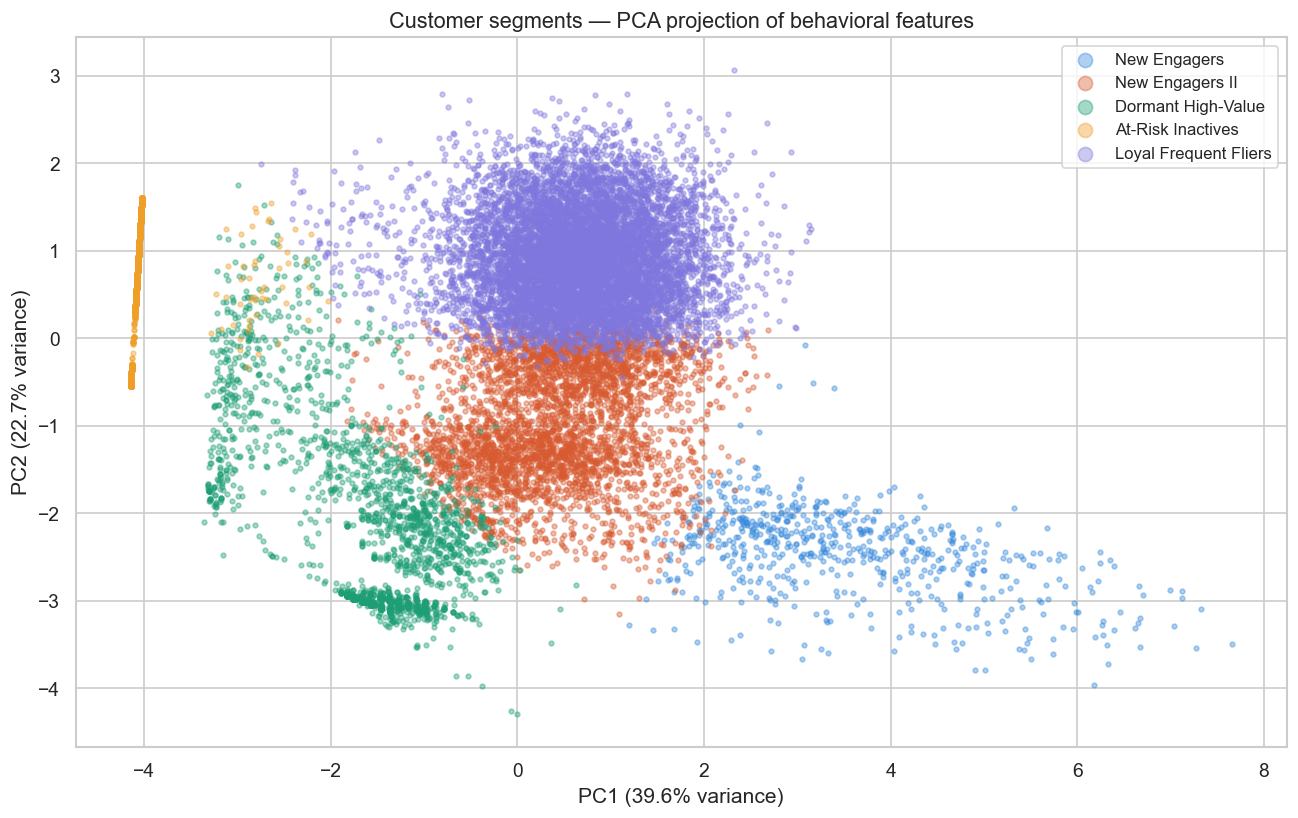

Saved → reports/figures/10_segments_pca.png


In [8]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

colors = ["#378ADD","#D85A30","#1D9E75","#EF9F27","#7F77DD"]
fig, ax = plt.subplots(figsize=(11, 7))

for i, (cluster_id, seg_name) in enumerate(segment_names.items()):
    mask = master["cluster"] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[i], alpha=0.4, s=8, label=seg_name)

ax.set_title("Customer segments — PCA projection of behavioral features", fontsize=13)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(markerscale=3, fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_segments_pca.png", bbox_inches="tight")
plt.show()
print("Saved → reports/figures/10_segments_pca.png")


## 9. Segment x Risk tier heatmap
Shows which segments have the most Critical-risk members — these are the priority for retention.

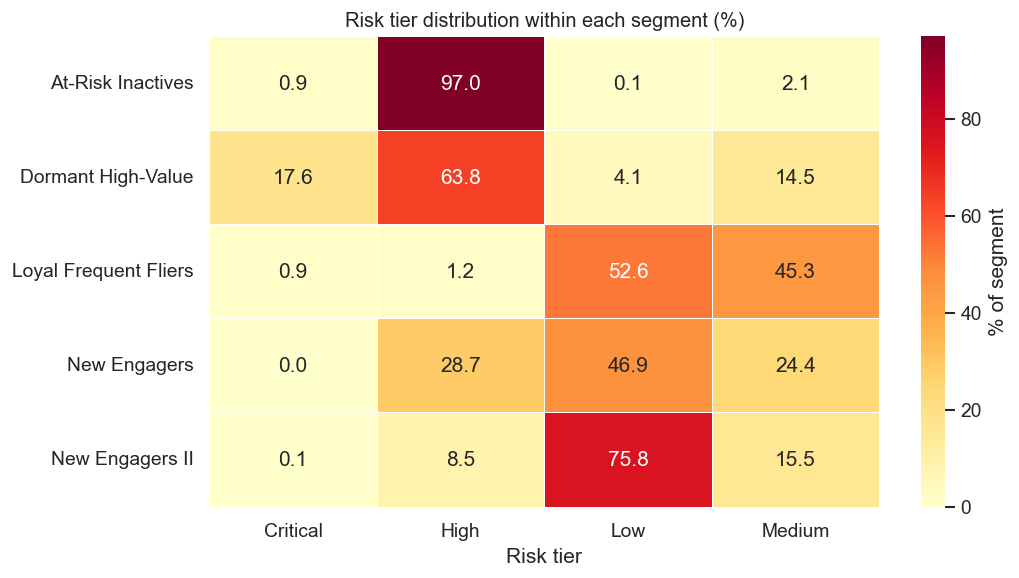

Saved → reports/figures/11_segment_risk_heatmap.png


In [9]:
cross = pd.crosstab(master["segment"], master["risk_tier"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(cross, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "% of segment"})
ax.set_title("Risk tier distribution within each segment (%)", fontsize=12)
ax.set_xlabel("Risk tier")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "11_segment_risk_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved → reports/figures/11_segment_risk_heatmap.png")


## 10. Retention playbook — one intervention per segment

In [10]:
playbook = {
    "Loyal Frequent Fliers": {
        "who"      : "High activity, recent flights, low churn risk",
        "trigger"  : "No special trigger — proactive reward",
        "action"   : "Offer early access to tier upgrade 3 months before threshold. "
                     "Send personalised milestone email (e.g. '500th flight') with exclusive lounge access.",
        "timeline" : "Quarterly touchpoint",
        "metric"   : "Tier upgrade conversion rate, NPS score"
    },
    "At-Risk Inactives": {
        "who"      : "Zero or near-zero flights in last 12+ months, still enrolled",
        "trigger"  : "No flight activity for 6 consecutive months",
        "action"   : "Send a re-engagement email with a time-limited double-points offer on next booking. "
                     "If no response in 30 days, follow up with a discounted companion fare.",
        "timeline" : "Month 1: email. Month 2: follow-up if no booking. Month 3: final win-back or flag for removal.",
        "metric"   : "Reactivation rate within 90 days"
    },
    "Dormant High-Value": {
        "who"      : "Above-average CLV but declining recent activity",
        "trigger"  : "Activity trend negative AND no flight in last 4 months",
        "action"   : "Personal outreach from account manager (not automated email). "
                     "Offer flexible booking credit worth 10% of their historical annual spend.",
        "timeline" : "Within 2 weeks of trigger. Monthly check-in for 3 months.",
        "metric"   : "Return to at least 1 flight within 60 days"
    },
    "New Engagers": {
        "who"      : "Low tenure, moderate activity — still forming habits",
        "trigger"  : "Enrolled less than 12 months ago",
        "action"   : "Onboarding nurture sequence: Month 1 explain tier benefits, "
                     "Month 2 highlight redemption options, Month 3 send first-anniversary bonus points.",
        "timeline" : "Automated 3-month onboarding sequence from enrollment date",
        "metric"   : "90-day retention rate, first redemption rate"
    },
    "Occasional Fliers": {
        "who"      : "Infrequent but consistent fliers, medium CLV",
        "trigger"  : "Gap of more than 3 months between flights",
        "action"   : "Seasonal campaign targeting their historically active quarter. "
                     "Offer bonus points on routes they have previously flown.",
        "timeline" : "Send 6 weeks before their historically active season",
        "metric"   : "Booking rate from campaign, seasonal revenue per member"
    }
}

print("=" * 60)
print("RETENTION PLAYBOOK")
print("=" * 60)
for seg, entry in playbook.items():
    # Only print if segment exists in data
    if seg in master["segment"].values or any(seg in s for s in master["segment"].unique()):
        print(f"\nSEGMENT: {seg}")
        print(f"  Who     : {entry['who']}")
        print(f"  Trigger : {entry['trigger']}")
        print(f"  Action  : {entry['action']}")
        print(f"  Timeline: {entry['timeline']}")
        print(f"  Metric  : {entry['metric']}")
        print("-" * 60)


RETENTION PLAYBOOK

SEGMENT: Loyal Frequent Fliers
  Who     : High activity, recent flights, low churn risk
  Trigger : No special trigger — proactive reward
  Action  : Offer early access to tier upgrade 3 months before threshold. Send personalised milestone email (e.g. '500th flight') with exclusive lounge access.
  Timeline: Quarterly touchpoint
  Metric  : Tier upgrade conversion rate, NPS score
------------------------------------------------------------

SEGMENT: At-Risk Inactives
  Who     : Zero or near-zero flights in last 12+ months, still enrolled
  Trigger : No flight activity for 6 consecutive months
  Action  : Send a re-engagement email with a time-limited double-points offer on next booking. If no response in 30 days, follow up with a discounted companion fare.
  Timeline: Month 1: email. Month 2: follow-up if no booking. Month 3: final win-back or flag for removal.
  Metric  : Reactivation rate within 90 days
-----------------------------------------------------------

## 11. Save final master file

In [11]:
master.to_csv(PROC / "master_features.csv", index=False)

print(f"Final master saved: {PROC}/master_features.csv")
print(f"Shape: {master.shape}")
print()
print("Columns added in this notebook:")
print("  cluster  — K-means cluster ID (0 to 4)")
print("  segment  — business-readable segment name")
print()
print("Notebook 04 complete.")



Final master saved: C:\Users\Madhur Gupta\airline-loyalty-intelligence\data\processed/master_features.csv
Shape: (16737, 43)

Columns added in this notebook:
  cluster  — K-means cluster ID (0 to 4)
  segment  — business-readable segment name

Notebook 04 complete.


In [12]:
print("=== SEGMENT DISTRIBUTION ===")
print(master["segment"].value_counts().to_dict())
print()
print("=== SEGMENT SUMMARY ===")
print(master.groupby("segment").agg(
    members=("Loyalty Number","count"),
    avg_clv=("CLV","mean"),
    avg_churn_prob=("churn_probability","mean"),
    avg_flights=("total_flights","mean"),
    avg_recency=("recency_months","mean"),
    churn_rate=("churned_behavioral","mean")
).round(2).to_string())
print()
print("=== RISK TIER DISTRIBUTION ===")
print(master["risk_tier"].value_counts().sort_index().to_dict())
print()
print("=== LOYALTY CARD BY SEGMENT ===")
print(pd.crosstab(master["segment"], master["Loyalty Card"]).to_string())
print()
print("=== COLUMNS IN FINAL MASTER ===")
print(master.columns.tolist())

=== SEGMENT DISTRIBUTION ===
{'Loyal Frequent Fliers': 8719, 'New Engagers II': 3814, 'Dormant High-Value': 1937, 'At-Risk Inactives': 1619, 'New Engagers': 648}

=== SEGMENT SUMMARY ===
                       members  avg_clv  avg_churn_prob  avg_flights  avg_recency  churn_rate
segment                                                                                      
At-Risk Inactives         1619  8341.02            0.00         0.38        23.76        0.00
Dormant High-Value        1937  8071.16            0.13         8.22         5.50        0.13
Loyal Frequent Fliers     8719  7963.40            0.00        39.05         0.84        0.00
New Engagers               648  8106.63            0.00        56.75         0.58        0.00
New Engagers II           3814  7835.93            0.00        30.15         0.73        0.00

=== RISK TIER DISTRIBUTION ===
{'Critical': 433, 'High': 3423, 'Low': 7863, 'Medium': 5018}

=== LOYALTY CARD BY SEGMENT ===
Loyalty Card           Aurora